# 12_model_training_lightgbm.ipynb — Entrenamiento LightGBM para DeepWave Canarias

Este notebook entrena el primer modelo predictivo sobre:

```text
gold/training_dataset/
```

Objetivo:

```text
Predecir altura significativa de ola futura y riesgo marítimo futuro.
```

Modelos entrenados:

```text
Persistence baseline
LightGBM Regressor +3h
LightGBM Regressor +6h
LightGBM Regressor +12h
LightGBM Regressor +24h
```

Targets:

```text
target_hs_3h
target_hs_6h
target_hs_12h
target_hs_24h
```

El riesgo se deriva desde la predicción de `hs`:

```text
pred_risk_3h
pred_risk_6h
pred_risk_12h
pred_risk_24h
```

Salidas:

```text
models/lightgbm/
gold/model_results/lightgbm/
```

Nota metodológica:

```text
Este notebook todavía no usa TCN/BiGRU. LightGBM funciona como benchmark fuerte y explicable para datos tabulares.
```

## Celda 0 — Montar Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Celda 1 — Instalar librerías

In [2]:
!pip -q install lightgbm scikit-learn pyarrow joblib matplotlib tqdm

## Celda 2 — Imports, rutas y configuración

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import joblib
import json
import shutil
import gc
import warnings
from tqdm.auto import tqdm

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

import lightgbm as lgb
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

BASE_DIR = Path("/content/drive/MyDrive/AI Projects/DeepWave Canarias")
GOLD_DIR = BASE_DIR / "gold"
GOLD_TRAINING_DIR = GOLD_DIR / "training_dataset"

MODELS_DIR = BASE_DIR / "models" / "lightgbm"
RESULTS_DIR = GOLD_DIR / "model_results" / "lightgbm"
QC_DIR = GOLD_DIR / "_quality_reports"
META_DIR = GOLD_DIR / "_metadata"

for d in [MODELS_DIR, RESULTS_DIR, QC_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

HORIZONS_HOURS = [3, 6, 12, 24]
TARGET_COLS = [f"target_hs_{h}h" for h in HORIZONS_HOURS]
TARGET_RISK_COLS = [f"target_risk_{h}h" for h in HORIZONS_HOURS]

RISK_THRESHOLDS = {
    "low_max": 1.0,
    "moderate_max": 2.0,
    "high_max": 3.0,
}

# Evaluación recomendada:
# True = usar solo zonas presentes en train, val y test.
# Evita evaluar zonas que nunca vio el modelo durante entrenamiento.
USE_COMMON_ZONES_ONLY = True

# Para pruebas rápidas si hiciera falta.
# Deja None para entrenamiento completo.
MAX_TRAIN_ROWS_PER_HORIZON = None
MAX_VAL_ROWS_PER_HORIZON = None
MAX_TEST_ROWS_PER_HORIZON = None

RANDOM_STATE = 42

# Columnas con demasiados nulos se excluyen automáticamente.
MAX_MISSING_PCT_FEATURE = 98.0

# Excluir zona_id como feature por defecto para evitar memorizar el identificador.
# Usaremos lat/lon, isla, orientación, batimetría y exposición como información espacial.
USE_ZONA_ID_AS_FEATURE = False

print("GOLD_TRAINING_DIR:", GOLD_TRAINING_DIR)
print("Existe:", GOLD_TRAINING_DIR.exists())

if not GOLD_TRAINING_DIR.exists():
    raise FileNotFoundError("No existe gold/training_dataset/. Ejecuta primero 11_gold_training_dataset.ipynb.")

GOLD_TRAINING_DIR: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/training_dataset
Existe: True


## Celda 3 — Funciones auxiliares

In [4]:
def ensure_utc(series):
    return pd.to_datetime(series, utc=True, errors="coerce")


def risk_level_from_hs_array(values):
    values = pd.to_numeric(pd.Series(values), errors="coerce")

    risk = pd.Series(np.nan, index=values.index, dtype="float64")

    risk.loc[values < RISK_THRESHOLDS["low_max"]] = 0
    risk.loc[(values >= RISK_THRESHOLDS["low_max"]) & (values < RISK_THRESHOLDS["moderate_max"])] = 1
    risk.loc[(values >= RISK_THRESHOLDS["moderate_max"]) & (values < RISK_THRESHOLDS["high_max"])] = 2
    risk.loc[values >= RISK_THRESHOLDS["high_max"]] = 3

    return risk.astype("Int64")


def regression_metrics(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors="coerce")
    y_pred = pd.to_numeric(pd.Series(y_pred), errors="coerce")

    mask = y_true.notna() & y_pred.notna()

    if mask.sum() == 0:
        return {
            "n": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "r2": np.nan,
            "bias": np.nan,
            "corr": np.nan,
        }

    yt = y_true[mask].values
    yp = y_pred[mask].values

    return {
        "n": int(mask.sum()),
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "r2": float(r2_score(yt, yp)) if len(np.unique(yt)) > 1 else np.nan,
        "bias": float(np.mean(yp - yt)),
        "corr": float(np.corrcoef(yt, yp)[0, 1]) if len(yt) > 1 and np.std(yt) > 0 and np.std(yp) > 0 else np.nan,
    }


def classification_metrics(y_true_risk, y_pred_risk):
    y_true_risk = pd.Series(y_true_risk).astype("Int64")
    y_pred_risk = pd.Series(y_pred_risk).astype("Int64")

    mask = y_true_risk.notna() & y_pred_risk.notna()

    if mask.sum() == 0:
        return {
            "n": 0,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
        }

    yt = y_true_risk[mask].astype(int).values
    yp = y_pred_risk[mask].astype(int).values

    labels = [0, 1, 2, 3]

    return {
        "n": int(mask.sum()),
        "accuracy": float(accuracy_score(yt, yp)),
        "balanced_accuracy": float(balanced_accuracy_score(yt, yp)),
        "macro_f1": float(f1_score(yt, yp, labels=labels, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(yt, yp, labels=labels, average="weighted", zero_division=0)),
    }


def sample_rows(df, max_rows, random_state=RANDOM_STATE):
    if max_rows is None or len(df) <= max_rows:
        return df

    return df.sample(n=max_rows, random_state=random_state).sort_index()


def memory_report(name, df):
    mb = df.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"{name}: shape={df.shape}, memoria≈{mb:.1f} MB")


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


def remove_if_exists(path):
    path = Path(path)
    if path.exists():
        if path.is_dir():
            shutil.rmtree(path)
        else:
            path.unlink()

## Celda 4 — Cargar Gold training dataset

In [5]:
dataset = ds.dataset(str(GOLD_TRAINING_DIR), format="parquet", partitioning="hive")
gold = dataset.to_table().to_pandas()

gold["timestamp"] = ensure_utc(gold["timestamp"])

# Asegurar split como string.
gold["split"] = gold["split"].astype(str)

print("Gold cargado:")
memory_report("gold", gold)

print("Splits:")
display(gold["split"].value_counts(dropna=False).reset_index())

print("Rango temporal:")
print(gold["timestamp"].min(), "→", gold["timestamp"].max())

print("Zonas:", gold["zona_id"].nunique())
display(gold.head())

Gold cargado:
gold: shape=(983328, 142), memoria≈1552.1 MB
Splits:


,split,count
0,train,698712
1,test,197256
2,val,87360


Rango temporal:
2015-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00
Zonas: 14


,timestamp,zona_id,simar_ocean_lat,simar_ocean_lon,simar_hs,simar_hmax,simar_tp,simar_tm02,simar_wave_direction,simar_swell_height,...,target_risk_24h,gold_dataset_version,target_source,risk_threshold_low_max,risk_threshold_moderate_max,risk_threshold_high_max,has_any_target,is_trainable_target_3h,split,year
0,2024-01-01 00:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.14,NaN,14.66,2.49,129,0.06,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
1,2024-01-01 01:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.14,NaN,14.66,2.57,270,0.06,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
2,2024-01-01 02:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.14,NaN,14.66,2.63,283,0.07,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
3,2024-01-01 03:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.15,NaN,14.66,2.53,303,0.07,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024
4,2024-01-01 04:00:00+00:00,CAN_FV_GRAN_TARAJAL,28.166667,-14.0,0.17,NaN,16.12,2.30,32,0.08,...,0,v1_silver_validated_simar_target,SIMAR,1.0,2.0,3.0,True,1,test,2024


## Celda 5 — Filtrar zonas comunes train/val/test

In [6]:
if USE_COMMON_ZONES_ONLY:
    zones_by_split = {
        split: set(gold.loc[gold["split"] == split, "zona_id"].dropna().astype(str).unique())
        for split in ["train", "val", "test"]
    }

    common_zones = set.intersection(*zones_by_split.values())

    print("Zonas train:", len(zones_by_split["train"]))
    print("Zonas val:", len(zones_by_split["val"]))
    print("Zonas test:", len(zones_by_split["test"]))
    print("Zonas comunes:", len(common_zones))

    if len(common_zones) == 0:
        raise ValueError("No hay zonas comunes entre train/val/test.")

    before = len(gold)
    gold = gold[gold["zona_id"].astype(str).isin(common_zones)].copy()
    after = len(gold)

    print(f"Filtrado a zonas comunes: {before:,} → {after:,} filas")

else:
    common_zones = set(gold["zona_id"].dropna().astype(str).unique())
    print("Se usan todas las zonas:", len(common_zones))

split_zone_summary = (
    gold.groupby("split", as_index=False)
    .agg(
        rows=("zona_id", "size"),
        zones=("zona_id", "nunique"),
        timestamp_min=("timestamp", "min"),
        timestamp_max=("timestamp", "max"),
    )
)

display(split_zone_summary)

split_zone_summary.to_csv(RESULTS_DIR / "split_zone_summary.csv", index=False)

Zonas train: 10
Zonas val: 10
Zonas test: 14
Zonas comunes: 10
Filtrado a zonas comunes: 983,328 → 960,384 filas


,split,rows,zones,timestamp_min,timestamp_max
0,test,174312,10,2024-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00
1,train,698712,10,2015-01-01 00:00:00+00:00,2022-12-31 23:00:00+00:00
2,val,87360,10,2023-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00


## Celda 6 — Selección automática de features

In [7]:
# Columnas que nunca deben entrar como features.
hard_exclude = set([
    "timestamp",
    "date",
    "split",
    "gold_dataset_version",
    "target_source",
    "has_any_target",
    "is_trainable_target_3h",
    "risk_threshold_low_max",
    "risk_threshold_moderate_max",
    "risk_threshold_high_max",
    "nombre_zona",
    "municipio",  # se puede activar en experimentos, pero puede tener ruido.
])

if not USE_ZONA_ID_AS_FEATURE:
    hard_exclude.add("zona_id")

# Excluir todos los targets y derivados de target.
for c in gold.columns:
    if c.startswith("target_"):
        hard_exclude.add(c)

# Excluir columnas claramente no predictivas o duplicadas de coordenadas internas si existen.
optional_exclude = [
    "simar_ocean_lat",
    "simar_ocean_lon",
]

for c in optional_exclude:
    if c in gold.columns:
        hard_exclude.add(c)

# Candidatas categóricas controladas.
categorical_candidates = [
    "zona_id" if USE_ZONA_ID_AS_FEATURE else None,
    "isla",
    "tipo_zona",
    "orientacion_costa",
    "vulnerabilidad_costera",
    "redmar_tide_phase",
]

categorical_candidates = [c for c in categorical_candidates if c is not None and c in gold.columns]

# Crear tabla de missing/nunique.
feature_audit_rows = []

for c in gold.columns:
    missing_pct = float(gold[c].isna().mean() * 100)
    nunique = int(gold[c].nunique(dropna=True))

    reason = ""
    use = True

    if c in hard_exclude:
        use = False
        reason = "hard_exclude"
    elif missing_pct >= MAX_MISSING_PCT_FEATURE:
        use = False
        reason = f"missing_pct_ge_{MAX_MISSING_PCT_FEATURE}"
    elif nunique <= 1:
        use = False
        reason = "constant_or_all_missing"
    elif str(gold[c].dtype).startswith("datetime"):
        use = False
        reason = "datetime"

    feature_audit_rows.append(
        {
            "column": c,
            "dtype": str(gold[c].dtype),
            "missing_pct": missing_pct,
            "nunique": nunique,
            "selected_feature": use,
            "reason_excluded": reason,
            "is_categorical": c in categorical_candidates,
        }
    )

feature_audit = pd.DataFrame(feature_audit_rows)

feature_cols = feature_audit.loc[feature_audit["selected_feature"], "column"].tolist()

# Separar categóricas y numéricas.
categorical_features = [c for c in categorical_candidates if c in feature_cols]
numeric_features = [c for c in feature_cols if c not in categorical_features]

print("Features seleccionadas:", len(feature_cols))
print("Numéricas:", len(numeric_features))
print("Categóricas:", categorical_features)

display(feature_audit.sort_values(["selected_feature", "missing_pct"], ascending=[True, False]).head(50))
display(feature_audit[feature_audit["selected_feature"]].head(100))

feature_audit.to_csv(RESULTS_DIR / "feature_selection_audit.csv", index=False)

save_json(
    {
        "feature_cols": feature_cols,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "use_common_zones_only": USE_COMMON_ZONES_ONLY,
        "use_zona_id_as_feature": USE_ZONA_ID_AS_FEATURE,
        "max_missing_pct_feature": MAX_MISSING_PCT_FEATURE,
        "horizons_hours": HORIZONS_HOURS,
        "risk_thresholds": RISK_THRESHOLDS,
    },
    RESULTS_DIR / "selected_features.json",
)

Features seleccionadas: 109
Numéricas: 106
Categóricas: ['isla', 'orientacion_costa', 'redmar_tide_phase']


,column,dtype,missing_pct,nunique,selected_feature,reason_excluded,is_categorical
5,simar_hmax,float64,100.000000,0,False,missing_pct_ge_98.0,False
13,simar_wind_wave_period,float64,100.000000,0,False,missing_pct_ge_98.0,False
14,simar_stokes_drift,float64,100.000000,0,False,missing_pct_ge_98.0,False
32,simar_wind_gust,float64,100.000000,0,False,missing_pct_ge_98.0,False
33,simar_temperature_air,float64,100.000000,0,False,missing_pct_ge_98.0,False
34,simar_pressure,float64,100.000000,0,False,missing_pct_ge_98.0,False
35,simar_precipitation,float64,100.000000,0,False,missing_pct_ge_98.0,False
36,simar_humidity,float64,100.000000,0,False,missing_pct_ge_98.0,False
128,target_hs_24h,float64,0.368603,705,False,hard_exclude,False
132,target_risk_24h,Int64,0.368603,4,False,hard_exclude,False


,column,dtype,missing_pct,nunique,selected_feature,reason_excluded,is_categorical
4,simar_hs,float64,0.000000,705,True,,False
6,simar_tp,float64,0.000000,1813,True,,False
7,simar_tm02,float64,0.000000,1329,True,,False
8,simar_wave_direction,int64,0.000000,360,True,,False
9,simar_swell_height,float64,0.000000,604,True,,False
...,...,...,...,...,...,...,...
112,simar_hs_lag_24h,float64,0.368603,705,True,,False
113,simar_tp_lag_24h,float64,0.368603,1813,True,,False
114,simar_wave_direction_lag_24h,float64,0.368603,360,True,,False
115,simar_wind_speed_lag_24h,float64,10.330868,1777,True,,False


## Celda 7 — Preparar tipos de datos para LightGBM

In [8]:
# Categóricas como category.
for c in categorical_features:
    gold[c] = gold[c].astype("string").fillna("UNKNOWN").astype("category")

# Numéricas a float32 para reducir memoria.
for c in numeric_features:
    gold[c] = pd.to_numeric(gold[c], errors="coerce").astype("float32")

# Targets a float32.
for c in TARGET_COLS:
    if c in gold.columns:
        gold[c] = pd.to_numeric(gold[c], errors="coerce").astype("float32")

memory_report("gold preparado", gold[feature_cols + TARGET_COLS + ["split", "timestamp", "zona_id"]])
display(gold[feature_cols].head())

gold preparado: shape=(960384, 116), memoria≈531.9 MB


,simar_hs,simar_tp,simar_tm02,simar_wave_direction,simar_swell_height,simar_swell_period,simar_swell_direction,simar_wind_wave_height,isla,zona_lat,...,simar_wind_direction_lag_24h,redmar_sea_level_lag_24h,simar_current_speed_lag_24h,simar_hs_roll_mean_6h,simar_hs_roll_max_12h,simar_hs_roll_mean_24h,simar_wind_speed_roll_mean_6h,simar_wind_speed_roll_max_12h,redmar_sea_level_roll_std_12h,year
0,0.14,14.660000,2.49,129.0,0.06,14.55,246.0,0.00,Fuerteventura,28.2113,...,NaN,1.428,0.195,0.145000,0.18,0.182500,NaN,NaN,0.403271,2024.0
1,0.14,14.660000,2.57,270.0,0.06,14.75,246.0,0.00,Fuerteventura,28.2113,...,NaN,1.835,0.194,0.143333,0.18,0.179167,NaN,NaN,0.375392,2024.0
2,0.14,14.660000,2.63,283.0,0.07,14.93,245.0,0.00,Fuerteventura,28.2113,...,NaN,2.201,0.188,0.141667,0.17,0.176667,NaN,NaN,0.363041,2024.0
3,0.15,14.660000,2.53,303.0,0.07,15.07,245.0,0.00,Fuerteventura,28.2113,...,NaN,2.438,0.162,0.140000,0.16,0.174167,NaN,NaN,0.368798,2024.0
4,0.17,16.120001,2.30,32.0,0.08,15.19,245.0,0.02,Fuerteventura,28.2113,...,NaN,2.494,0.113,0.141667,0.16,0.172500,NaN,NaN,0.390377,2024.0


## Celda 8 — Función de entrenamiento por horizonte

In [9]:
def prepare_xy(df, feature_cols, target_col, max_rows=None):
    work = df[df[target_col].notna()].copy()

    work = sample_rows(work, max_rows=max_rows)

    X = work[feature_cols].copy()
    y = work[target_col].astype("float32")

    return X, y, work


def train_lgbm_for_horizon(horizon):
    target_col = f"target_hs_{horizon}h"
    risk_col = f"target_risk_{horizon}h"

    print("=" * 80)
    print(f"Entrenando horizonte +{horizon}h")
    print("Target:", target_col)

    train_df = gold[gold["split"] == "train"].copy()
    val_df = gold[gold["split"] == "val"].copy()
    test_df = gold[gold["split"] == "test"].copy()

    X_train, y_train, train_used = prepare_xy(
        train_df,
        feature_cols,
        target_col,
        max_rows=MAX_TRAIN_ROWS_PER_HORIZON,
    )

    X_val, y_val, val_used = prepare_xy(
        val_df,
        feature_cols,
        target_col,
        max_rows=MAX_VAL_ROWS_PER_HORIZON,
    )

    X_test, y_test, test_used = prepare_xy(
        test_df,
        feature_cols,
        target_col,
        max_rows=MAX_TEST_ROWS_PER_HORIZON,
    )

    print("Train:", X_train.shape)
    print("Val:", X_val.shape)
    print("Test:", X_test.shape)

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise ValueError(f"Algún split está vacío para {target_col}")

    model = LGBMRegressor(
        objective="regression",
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=-1,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.85,
        min_child_samples=50,
        reg_alpha=0.05,
        reg_lambda=0.2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )

    callbacks = [
        lgb.early_stopping(stopping_rounds=150, verbose=True),
        lgb.log_evaluation(period=100),
    ]

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric=["l1", "rmse"],
        categorical_feature=categorical_features if categorical_features else "auto",
        callbacks=callbacks,
    )

    # Predicciones.
    pred_train = model.predict(X_train, num_iteration=model.best_iteration_)
    pred_val = model.predict(X_val, num_iteration=model.best_iteration_)
    pred_test = model.predict(X_test, num_iteration=model.best_iteration_)

    pred_train = np.clip(pred_train, 0, None)
    pred_val = np.clip(pred_val, 0, None)
    pred_test = np.clip(pred_test, 0, None)

    # Baseline persistencia.
    baseline_train = train_used["simar_hs"].values
    baseline_val = val_used["simar_hs"].values
    baseline_test = test_used["simar_hs"].values

    metrics_rows = []

    for split_name, y_true, pred_lgbm, pred_base in [
        ("train", y_train, pred_train, baseline_train),
        ("val", y_val, pred_val, baseline_val),
        ("test", y_test, pred_test, baseline_test),
    ]:
        m_lgbm = regression_metrics(y_true, pred_lgbm)
        m_base = regression_metrics(y_true, pred_base)

        metrics_rows.append(
            {
                "horizon_hours": horizon,
                "target": target_col,
                "split": split_name,
                "model": "LightGBM",
                **m_lgbm,
                "best_iteration": int(model.best_iteration_) if model.best_iteration_ else np.nan,
            }
        )

        metrics_rows.append(
            {
                "horizon_hours": horizon,
                "target": target_col,
                "split": split_name,
                "model": "Persistence",
                **m_base,
                "best_iteration": np.nan,
            }
        )

    regression_metrics_df = pd.DataFrame(metrics_rows)

    # Riesgo derivado.
    risk_rows = []

    for split_name, used_df, y_true, pred_lgbm, pred_base in [
        ("train", train_used, y_train, pred_train, baseline_train),
        ("val", val_used, y_val, pred_val, baseline_val),
        ("test", test_used, y_test, pred_test, baseline_test),
    ]:
        true_risk = risk_level_from_hs_array(y_true)
        pred_risk_lgbm = risk_level_from_hs_array(pred_lgbm)
        pred_risk_base = risk_level_from_hs_array(pred_base)

        cm_lgbm = confusion_matrix(
            true_risk.dropna().astype(int),
            pred_risk_lgbm[true_risk.notna()].astype(int),
            labels=[0, 1, 2, 3],
        )

        cm_base = confusion_matrix(
            true_risk.dropna().astype(int),
            pred_risk_base[true_risk.notna()].astype(int),
            labels=[0, 1, 2, 3],
        )

        pd.DataFrame(
            cm_lgbm,
            index=[f"true_{i}" for i in [0, 1, 2, 3]],
            columns=[f"pred_{i}" for i in [0, 1, 2, 3]],
        ).to_csv(RESULTS_DIR / f"confusion_matrix_lgbm_h{horizon}_{split_name}.csv")

        pd.DataFrame(
            cm_base,
            index=[f"true_{i}" for i in [0, 1, 2, 3]],
            columns=[f"pred_{i}" for i in [0, 1, 2, 3]],
        ).to_csv(RESULTS_DIR / f"confusion_matrix_persistence_h{horizon}_{split_name}.csv")

        risk_rows.append(
            {
                "horizon_hours": horizon,
                "split": split_name,
                "model": "LightGBM",
                **classification_metrics(true_risk, pred_risk_lgbm),
            }
        )

        risk_rows.append(
            {
                "horizon_hours": horizon,
                "split": split_name,
                "model": "Persistence",
                **classification_metrics(true_risk, pred_risk_base),
            }
        )

    risk_metrics_df = pd.DataFrame(risk_rows)

    # Predicciones test/val para análisis.
    pred_val_df = val_used[
        ["zona_id", "timestamp", "split", "isla", "lat", "lon", "simar_hs", target_col]
    ].copy()

    pred_val_df["horizon_hours"] = horizon
    pred_val_df["y_true"] = y_val.values
    pred_val_df["pred_lgbm"] = pred_val
    pred_val_df["pred_persistence"] = baseline_val
    pred_val_df["true_risk"] = risk_level_from_hs_array(pred_val_df["y_true"]).values
    pred_val_df["pred_risk_lgbm"] = risk_level_from_hs_array(pred_val_df["pred_lgbm"]).values
    pred_val_df["pred_risk_persistence"] = risk_level_from_hs_array(pred_val_df["pred_persistence"]).values

    pred_test_df = test_used[
        ["zona_id", "timestamp", "split", "isla", "lat", "lon", "simar_hs", target_col]
    ].copy()

    pred_test_df["horizon_hours"] = horizon
    pred_test_df["y_true"] = y_test.values
    pred_test_df["pred_lgbm"] = pred_test
    pred_test_df["pred_persistence"] = baseline_test
    pred_test_df["true_risk"] = risk_level_from_hs_array(pred_test_df["y_true"]).values
    pred_test_df["pred_risk_lgbm"] = risk_level_from_hs_array(pred_test_df["pred_lgbm"]).values
    pred_test_df["pred_risk_persistence"] = risk_level_from_hs_array(pred_test_df["pred_persistence"]).values

    predictions_df = pd.concat([pred_val_df, pred_test_df], ignore_index=True)

    # Feature importance.
    importance_df = pd.DataFrame(
        {
            "feature": feature_cols,
            "importance_gain": model.booster_.feature_importance(importance_type="gain"),
            "importance_split": model.booster_.feature_importance(importance_type="split"),
            "horizon_hours": horizon,
        }
    ).sort_values("importance_gain", ascending=False)

    # Guardar modelo.
    model_path = MODELS_DIR / f"lightgbm_hs_{horizon}h.pkl"
    joblib.dump(model, model_path)

    print("Modelo guardado:", model_path)

    return {
        "horizon": horizon,
        "model": model,
        "regression_metrics": regression_metrics_df,
        "risk_metrics": risk_metrics_df,
        "predictions": predictions_df,
        "importance": importance_df,
        "model_path": str(model_path),
    }

parche 8b

In [11]:
def risk_level_from_hs_array(values):
    """
    Versión robusta:
    - Siempre devuelve Series con RangeIndex 0..n-1.
    - Evita errores de alineación entre y_true y predicciones.
    """
    values = pd.Series(np.asarray(values), dtype="float64")

    risk = pd.Series(np.nan, index=values.index, dtype="float64")

    risk.loc[values < RISK_THRESHOLDS["low_max"]] = 0
    risk.loc[
        (values >= RISK_THRESHOLDS["low_max"])
        & (values < RISK_THRESHOLDS["moderate_max"])
    ] = 1
    risk.loc[
        (values >= RISK_THRESHOLDS["moderate_max"])
        & (values < RISK_THRESHOLDS["high_max"])
    ] = 2
    risk.loc[values >= RISK_THRESHOLDS["high_max"]] = 3

    return risk.astype("Int64")


def classification_metrics(y_true_risk, y_pred_risk):
    """
    Versión robusta sin alineación por índice pandas.
    """
    y_true_risk = pd.Series(np.asarray(y_true_risk), dtype="Int64")
    y_pred_risk = pd.Series(np.asarray(y_pred_risk), dtype="Int64")

    mask = y_true_risk.notna() & y_pred_risk.notna()

    if mask.sum() == 0:
        return {
            "n": 0,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
        }

    yt = y_true_risk[mask].astype(int).values
    yp = y_pred_risk[mask].astype(int).values

    labels = [0, 1, 2, 3]

    return {
        "n": int(mask.sum()),
        "accuracy": float(accuracy_score(yt, yp)),
        "balanced_accuracy": float(balanced_accuracy_score(yt, yp)),
        "macro_f1": float(f1_score(yt, yp, labels=labels, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(yt, yp, labels=labels, average="weighted", zero_division=0)),
    }


print("Parche 8B cargado: índices de riesgo corregidos.")

Parche 8B cargado: índices de riesgo corregidos.


## Celda 9 — Entrenar modelos LightGBM por horizonte

In [12]:
training_results = []

for h in HORIZONS_HOURS:
    result = train_lgbm_for_horizon(h)
    training_results.append(result)

print("Modelos entrenados:", len(training_results))

Entrenando horizonte +3h
Target: target_hs_3h
Train: (698181, 109)
Val: (87300, 109)
Test: (174135, 109)
Training until validation scores don't improve for 150 rounds
[100]	valid_0's l1: 0.0756585	valid_0's rmse: 0.109334	valid_0's l2: 0.0119539
[200]	valid_0's l1: 0.063715	valid_0's rmse: 0.0970552	valid_0's l2: 0.0094197
[300]	valid_0's l1: 0.0619756	valid_0's rmse: 0.0947497	valid_0's l2: 0.0089775
[400]	valid_0's l1: 0.0610787	valid_0's rmse: 0.0934738	valid_0's l2: 0.00873735
[500]	valid_0's l1: 0.0605777	valid_0's rmse: 0.0927525	valid_0's l2: 0.00860304
[600]	valid_0's l1: 0.0602035	valid_0's rmse: 0.0921596	valid_0's l2: 0.00849339
[700]	valid_0's l1: 0.0598985	valid_0's rmse: 0.0916812	valid_0's l2: 0.00840545
[800]	valid_0's l1: 0.0597347	valid_0's rmse: 0.0913821	valid_0's l2: 0.00835069
[900]	valid_0's l1: 0.0595082	valid_0's rmse: 0.0910426	valid_0's l2: 0.00828875
[1000]	valid_0's l1: 0.0593831	valid_0's rmse: 0.0908237	valid_0's l2: 0.00824895
[1100]	valid_0's l1: 0.0592

## Celda 10 — Consolidar métricas y guardar resultados

In [13]:
regression_metrics_all = pd.concat(
    [r["regression_metrics"] for r in training_results],
    ignore_index=True,
)

risk_metrics_all = pd.concat(
    [r["risk_metrics"] for r in training_results],
    ignore_index=True,
)

predictions_all = pd.concat(
    [r["predictions"] for r in training_results],
    ignore_index=True,
)

feature_importance_all = pd.concat(
    [r["importance"] for r in training_results],
    ignore_index=True,
)

regression_metrics_all.to_csv(RESULTS_DIR / "metrics_regression.csv", index=False)
risk_metrics_all.to_csv(RESULTS_DIR / "metrics_risk.csv", index=False)
feature_importance_all.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)

predictions_all.to_parquet(
    RESULTS_DIR / "val_test_predictions.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy",
)

display(regression_metrics_all)
display(risk_metrics_all)
display(feature_importance_all.head(40))
display(predictions_all.head())

print("Resultados guardados en:", RESULTS_DIR)

,horizon_hours,target,split,model,n,mae,rmse,r2,bias,corr,best_iteration
0,3,target_hs_3h,train,LightGBM,500634,0.872269,1.112505,-1.112280,0.065828,-0.046290,2943.0
1,3,target_hs_3h,train,Persistence,500634,0.874140,1.115483,-1.123602,0.065718,-0.046205,NaN
2,3,target_hs_3h,val,LightGBM,0,NaN,NaN,NaN,NaN,NaN,2943.0
3,3,target_hs_3h,val,Persistence,0,NaN,NaN,NaN,NaN,NaN,NaN
4,3,target_hs_3h,test,LightGBM,162504,0.567302,0.864137,-0.162504,0.043345,0.399418,2943.0
5,3,target_hs_3h,test,Persistence,162504,0.556629,0.868671,-0.174734,0.044525,0.406176,NaN
6,6,target_hs_6h,train,LightGBM,499812,0.868822,1.105307,-1.084416,0.065618,-0.044420,1980.0
7,6,target_hs_6h,train,Persistence,499812,0.875146,1.114193,-1.118064,0.065330,-0.043816,NaN
8,6,target_hs_6h,val,LightGBM,0,NaN,NaN,NaN,NaN,NaN,1980.0
9,6,target_hs_6h,val,Persistence,0,NaN,NaN,NaN,NaN,NaN,NaN


,horizon_hours,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,3,train,LightGBM,698181,0.963558,0.957701,0.960218,0.963533
1,3,train,Persistence,698181,0.929232,0.917831,0.917855,0.929229
2,3,val,LightGBM,87300,0.948992,0.932388,0.939092,0.948916
3,3,val,Persistence,87300,0.923219,0.909474,0.909533,0.923215
4,3,test,LightGBM,174135,0.944767,0.934673,0.939179,0.944729
5,3,test,Persistence,174135,0.918489,0.909337,0.909224,0.918493
6,6,train,LightGBM,697650,0.931081,0.917731,0.924035,0.930981
7,6,train,Persistence,697650,0.875405,0.853892,0.853924,0.875396
8,6,val,LightGBM,87240,0.901032,0.865697,0.882035,0.900684
9,6,val,Persistence,87240,0.865463,0.840270,0.840385,0.865444


,feature,importance_gain,importance_split,horizon_hours
0,simar_hs,4.827723e+06,8518,3
1,simar_hs_lag_1h,7.429433e+05,7048,3
2,simar_hs_lag_3h,1.471515e+05,4192,3
3,simar_hs_roll_mean_6h,2.865419e+04,1307,3
4,simar_hs_lag_6h,5.503086e+03,2776,3
5,simar_wind_speed,4.690971e+03,3460,3
6,simar_tp,4.149751e+03,2293,3
7,simar_tm02,2.868193e+03,3845,3
8,simar_hs_roll_max_12h,2.628743e+03,2357,3
9,simar_v10,1.904688e+03,3143,3


,zona_id,timestamp,split,isla,lat,lon,simar_hs,target_hs_3h,horizon_hours,y_true,pred_lgbm,pred_persistence,true_risk,pred_risk_lgbm,pred_risk_persistence,target_hs_6h,target_hs_12h,target_hs_24h
0,CAN_FV_GRAN_TARAJAL,2023-01-01 00:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.50,0.52,3,0.52,0.620382,0.50,0,0,0,NaN,NaN,NaN
1,CAN_FV_GRAN_TARAJAL,2023-01-01 01:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.45,0.79,3,0.79,0.569245,0.45,0,0,0,NaN,NaN,NaN
2,CAN_FV_GRAN_TARAJAL,2023-01-01 02:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.43,1.05,3,1.05,0.561176,0.43,1,0,0,NaN,NaN,NaN
3,CAN_FV_GRAN_TARAJAL,2023-01-01 03:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.52,1.22,3,1.22,0.705358,0.52,1,0,0,NaN,NaN,NaN
4,CAN_FV_GRAN_TARAJAL,2023-01-01 04:00:00+00:00,val,Fuerteventura,28.2113,-14.0195,0.79,1.28,3,1.28,1.103930,0.79,1,1,0,NaN,NaN,NaN


Resultados guardados en: /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm


## Celda 11 — Comparativa principal en test

In [14]:
test_regression = regression_metrics_all[
    regression_metrics_all["split"] == "test"
].copy()

test_pivot = test_regression.pivot_table(
    index=["horizon_hours", "target"],
    columns="model",
    values=["mae", "rmse", "r2", "corr", "bias"],
)

display(test_pivot)

# Mejora porcentual frente a persistencia.
improvement_rows = []

for h in HORIZONS_HOURS:
    subset = test_regression[test_regression["horizon_hours"] == h]

    lgbm = subset[subset["model"] == "LightGBM"].iloc[0]
    base = subset[subset["model"] == "Persistence"].iloc[0]

    improvement_rows.append(
        {
            "horizon_hours": h,
            "mae_persistence": base["mae"],
            "mae_lgbm": lgbm["mae"],
            "mae_improvement_pct": float((base["mae"] - lgbm["mae"]) / base["mae"] * 100) if base["mae"] > 0 else np.nan,
            "rmse_persistence": base["rmse"],
            "rmse_lgbm": lgbm["rmse"],
            "rmse_improvement_pct": float((base["rmse"] - lgbm["rmse"]) / base["rmse"] * 100) if base["rmse"] > 0 else np.nan,
            "r2_lgbm": lgbm["r2"],
            "corr_lgbm": lgbm["corr"],
        }
    )

improvement_df = pd.DataFrame(improvement_rows)
display(improvement_df)

improvement_df.to_csv(RESULTS_DIR / "test_improvement_vs_persistence.csv", index=False)

bias                  corr              \
model                        LightGBM Persistence  LightGBM Persistence   
horizon_hours target                                                      
3             target_hs_3h   0.043345    0.044525  0.399418    0.406176   
6             target_hs_6h   0.044303    0.044828  0.347952    0.358090   
12            target_hs_12h  0.043855    0.045005  0.287031    0.292750   
24            target_hs_24h  0.032217    0.042381  0.260842    0.233887   

                                  mae                    r2              \
model                        LightGBM Persistence  LightGBM Persistence   
horizon_hours target                                                      
3             target_hs_3h   0.567302    0.556629 -0.162504   -0.174734   
6             target_hs_6h   0.617189    0.611747 -0.229079   -0.270411   
12            target_hs_12h  0.653216    0.670247 -0.266967   -0.400051   
24            target_hs_24h  0.641059    0.708889 -0.175174   -0.511796   

                                 rmse              
model                        LightGBM Persistence  
horizon_hours target                               
3             target_hs_3h   0.864137    0.868671  
6             target_hs_6h   0.888466    0.903282  
12            target_hs_12h  0.902948    0.949188  
24            target_hs_24h  0.870058    0.986833

,horizon_hours,mae_persistence,mae_lgbm,mae_improvement_pct,rmse_persistence,rmse_lgbm,rmse_improvement_pct,r2_lgbm,corr_lgbm
0,3,0.556629,0.567302,-1.917410,0.868671,0.864137,0.521884,-0.162504,0.399418
1,6,0.611747,0.617189,-0.889575,0.903282,0.888466,1.640186,-0.229079,0.347952
2,12,0.670247,0.653216,2.540913,0.949188,0.902948,4.871505,-0.266967,0.287031
3,24,0.708889,0.641059,9.568517,0.986833,0.870058,11.833291,-0.175174,0.260842


## Celda 12 — Gráficos de métricas

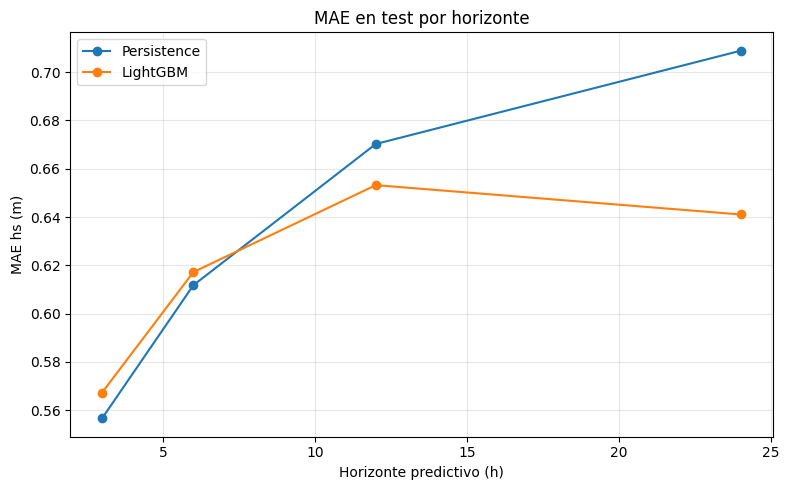

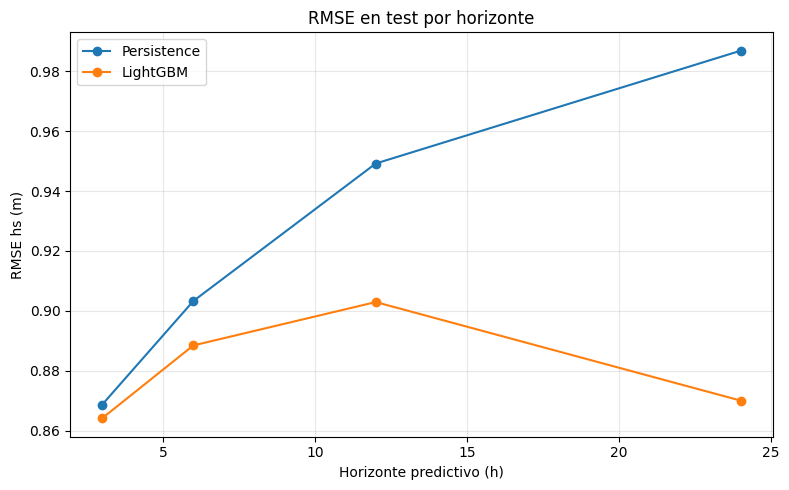

In [15]:
# MAE por horizonte.
plt.figure(figsize=(8, 5))

for model_name in ["Persistence", "LightGBM"]:
    data = test_regression[test_regression["model"] == model_name].sort_values("horizon_hours")
    plt.plot(data["horizon_hours"], data["mae"], marker="o", label=model_name)

plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("MAE hs (m)")
plt.title("MAE en test por horizonte")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "plot_test_mae_by_horizon.png", dpi=150)
plt.show()

# RMSE por horizonte.
plt.figure(figsize=(8, 5))

for model_name in ["Persistence", "LightGBM"]:
    data = test_regression[test_regression["model"] == model_name].sort_values("horizon_hours")
    plt.plot(data["horizon_hours"], data["rmse"], marker="o", label=model_name)

plt.xlabel("Horizonte predictivo (h)")
plt.ylabel("RMSE hs (m)")
plt.title("RMSE en test por horizonte")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "plot_test_rmse_by_horizon.png", dpi=150)
plt.show()

## Celda 13 — Gráficos predicción vs real

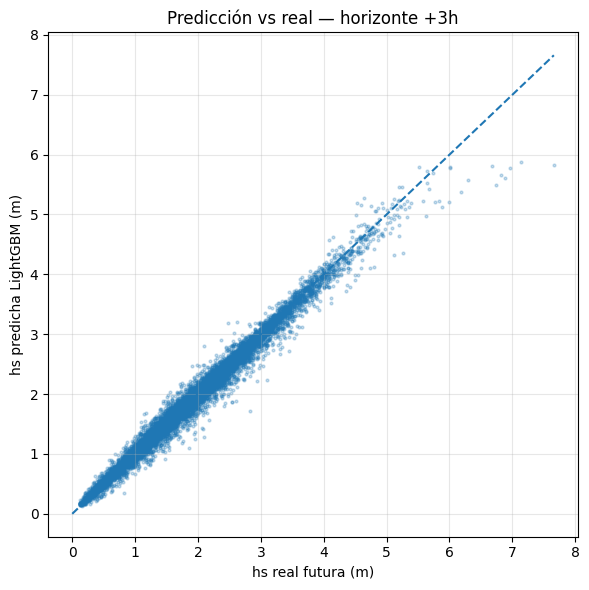

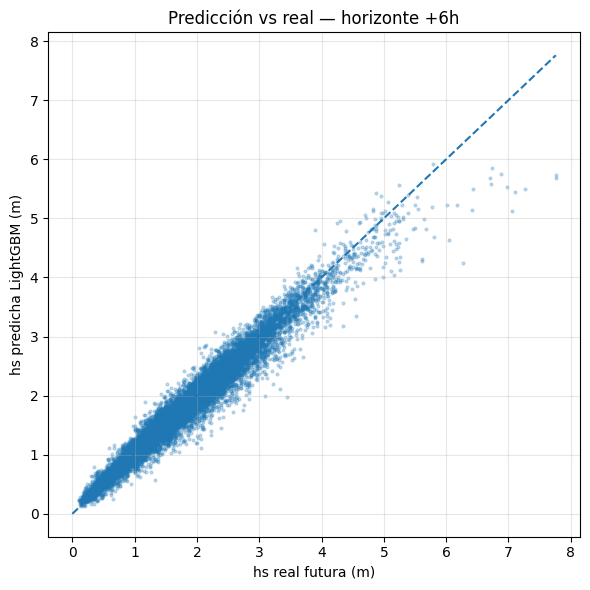

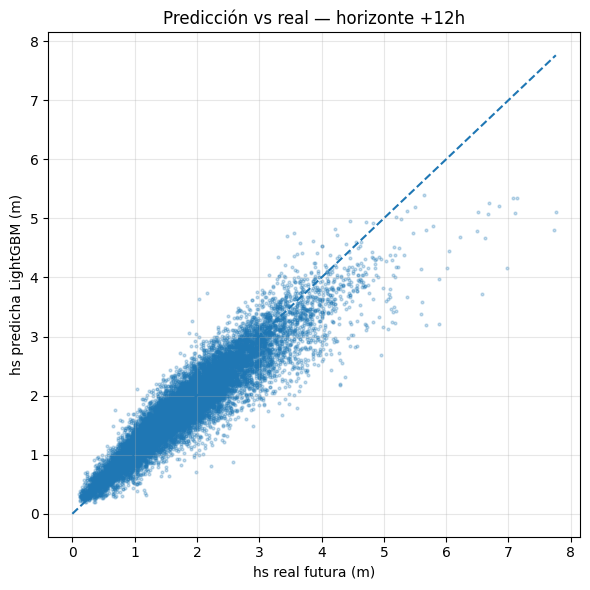

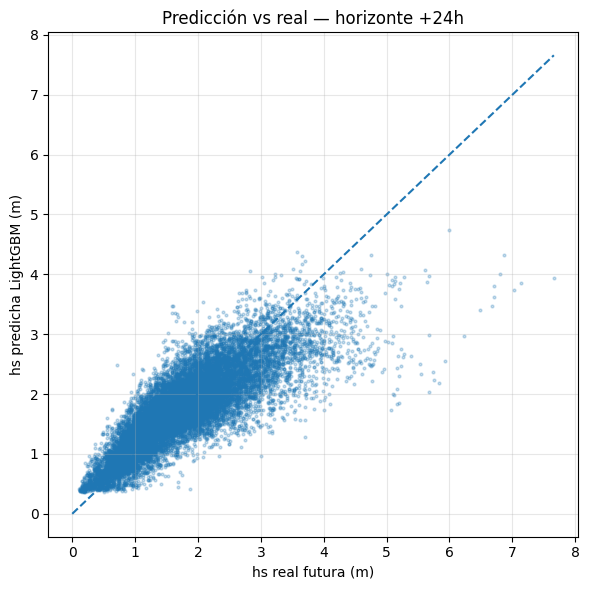

In [16]:
for h in HORIZONS_HOURS:
    plot_df = predictions_all[
        (predictions_all["split"] == "test")
        & (predictions_all["horizon_hours"] == h)
    ].copy()

    if len(plot_df) > 20000:
        plot_df = plot_df.sample(20000, random_state=RANDOM_STATE)

    plt.figure(figsize=(6, 6))
    plt.scatter(plot_df["y_true"], plot_df["pred_lgbm"], s=4, alpha=0.25)

    max_val = np.nanmax([plot_df["y_true"].max(), plot_df["pred_lgbm"].max()])
    plt.plot([0, max_val], [0, max_val], linestyle="--")

    plt.xlabel("hs real futura (m)")
    plt.ylabel("hs predicha LightGBM (m)")
    plt.title(f"Predicción vs real — horizonte +{h}h")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"plot_pred_vs_true_h{h}.png", dpi=150)
    plt.show()

## Celda 14 — Importancia de variables

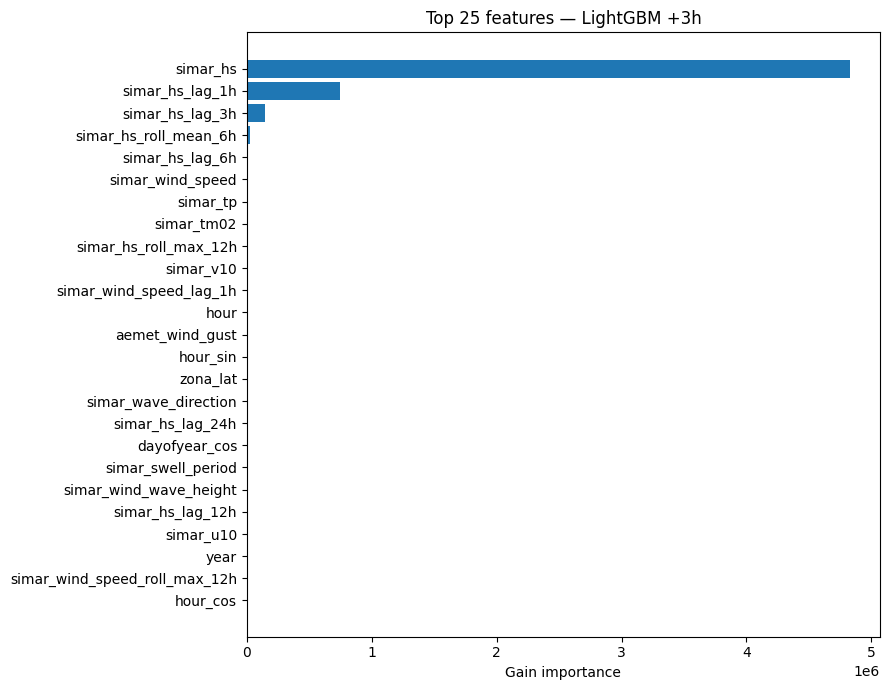

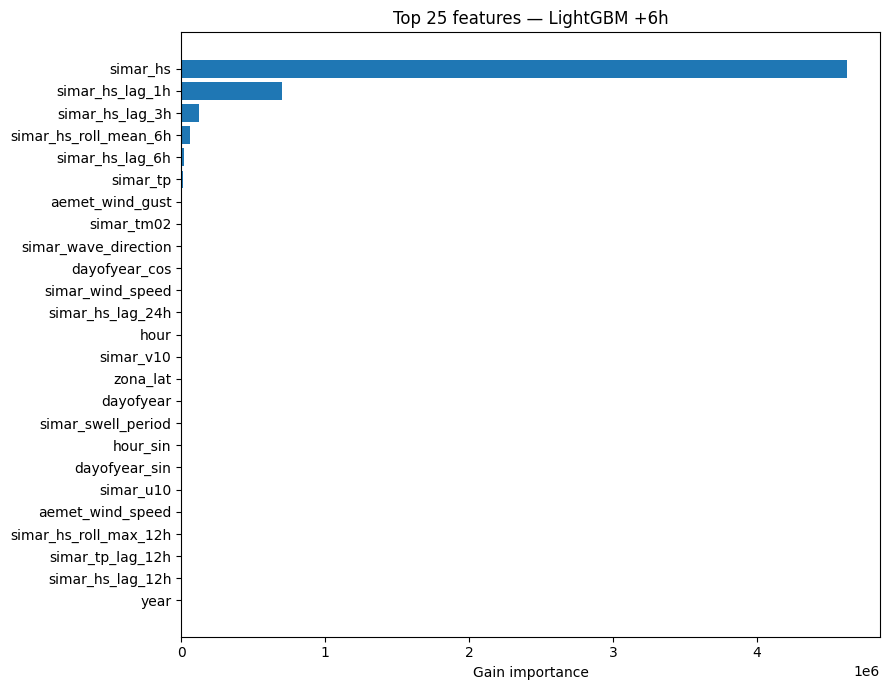

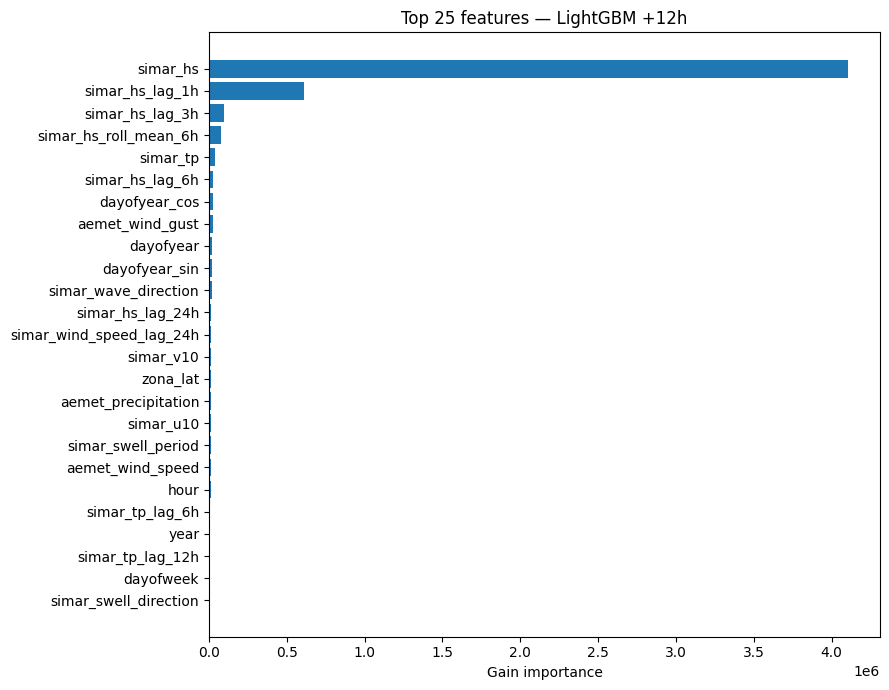

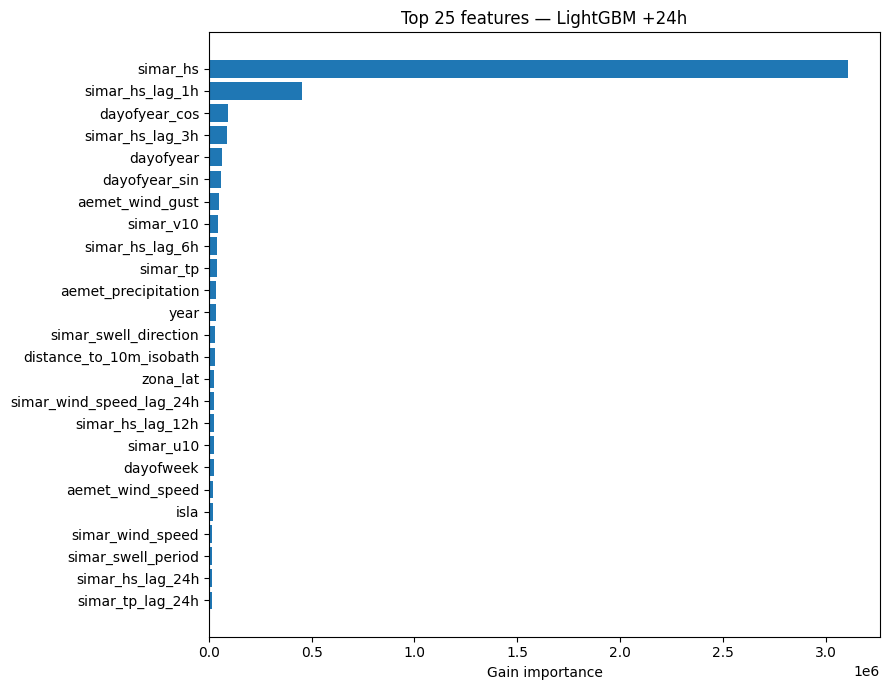

In [17]:
for h in HORIZONS_HOURS:
    imp = feature_importance_all[
        feature_importance_all["horizon_hours"] == h
    ].sort_values("importance_gain", ascending=False).head(25)

    plt.figure(figsize=(9, 7))
    plt.barh(imp["feature"][::-1], imp["importance_gain"][::-1])
    plt.xlabel("Gain importance")
    plt.title(f"Top 25 features — LightGBM +{h}h")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"plot_feature_importance_h{h}.png", dpi=150)
    plt.show()

## Celda 15 — Reportes de clasificación de riesgo en test

In [18]:
classification_reports = []

for h in HORIZONS_HOURS:
    df_h = predictions_all[
        (predictions_all["split"] == "test")
        & (predictions_all["horizon_hours"] == h)
    ].copy()

    y_true = df_h["true_risk"].astype("Int64")
    y_pred = df_h["pred_risk_lgbm"].astype("Int64")

    mask = y_true.notna() & y_pred.notna()

    report = classification_report(
        y_true[mask].astype(int),
        y_pred[mask].astype(int),
        labels=[0, 1, 2, 3],
        output_dict=True,
        zero_division=0,
    )

    report_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})
    report_df["horizon_hours"] = h
    classification_reports.append(report_df)

classification_report_all = pd.concat(classification_reports, ignore_index=True)
display(classification_report_all)

classification_report_all.to_csv(RESULTS_DIR / "classification_report_test_lgbm.csv", index=False)

,class,precision,recall,f1-score,support,horizon_hours
0,0,0.941726,0.934023,0.937859,25797.000000,3
1,1,0.953216,0.960209,0.956700,91327.000000,3
2,2,0.925868,0.927224,0.926546,43696.000000,3
3,3,0.954737,0.917236,0.935611,13315.000000,3
4,accuracy,0.944767,0.944767,0.944767,0.944767,3
5,macro avg,0.943887,0.934673,0.939179,174135.000000,3
6,weighted avg,0.944768,0.944767,0.944729,174135.000000,3
7,0,0.912334,0.867955,0.889591,25779.000000,6
8,1,0.912838,0.929925,0.921302,91245.000000,6
9,2,0.851217,0.867681,0.859370,43637.000000,6


## Celda 16 — Guardar configuración de entrenamiento

In [19]:
training_config = {
    "model_family": "LightGBMRegressor",
    "target_source": "SIMAR",
    "horizons_hours": HORIZONS_HOURS,
    "risk_thresholds": RISK_THRESHOLDS,
    "use_common_zones_only": USE_COMMON_ZONES_ONLY,
    "common_zones_count": len(common_zones),
    "common_zones": sorted(list(common_zones)),
    "use_zona_id_as_feature": USE_ZONA_ID_AS_FEATURE,
    "max_missing_pct_feature": MAX_MISSING_PCT_FEATURE,
    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "max_train_rows_per_horizon": MAX_TRAIN_ROWS_PER_HORIZON,
    "random_state": RANDOM_STATE,
    "models": {
        f"hs_{r['horizon']}h": r["model_path"]
        for r in training_results
    },
}

save_json(training_config, RESULTS_DIR / "training_config.json")
save_json(training_config, MODELS_DIR / "training_config.json")

print("Configuración guardada.")
print(RESULTS_DIR / "training_config.json")
print(MODELS_DIR / "training_config.json")

Configuración guardada.
/content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm/training_config.json
/content/drive/MyDrive/AI Projects/DeepWave Canarias/models/lightgbm/training_config.json


## Celda 17 — Validación final del entrenamiento

In [20]:
required_files = [
    RESULTS_DIR / "metrics_regression.csv",
    RESULTS_DIR / "metrics_risk.csv",
    RESULTS_DIR / "feature_importance.csv",
    RESULTS_DIR / "val_test_predictions.parquet",
    RESULTS_DIR / "test_improvement_vs_persistence.csv",
    RESULTS_DIR / "training_config.json",
]

for h in HORIZONS_HOURS:
    required_files.append(MODELS_DIR / f"lightgbm_hs_{h}h.pkl")

missing_files = [str(p) for p in required_files if not Path(p).exists()]

if missing_files:
    raise FileNotFoundError("Faltan archivos de salida: " + json.dumps(missing_files, indent=2))

# Comprobación mínima: LightGBM debe tener métricas en test para todos los horizontes.
test_lgbm = regression_metrics_all[
    (regression_metrics_all["split"] == "test")
    & (regression_metrics_all["model"] == "LightGBM")
]

if test_lgbm["horizon_hours"].nunique() != len(HORIZONS_HOURS):
    raise ValueError("No hay métricas test LightGBM para todos los horizontes.")

if test_lgbm["mae"].isna().any() or test_lgbm["rmse"].isna().any():
    raise ValueError("Hay métricas MAE/RMSE nulas en test.")

print("Archivos generados:")
for p in sorted(RESULTS_DIR.glob("*")):
    print("-", p)

print("\nModelos generados:")
for p in sorted(MODELS_DIR.glob("*.pkl")):
    print("-", p)

print("\n✅ Entrenamiento LightGBM completado correctamente.")

Archivos generados:
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm/classification_report_test_lgbm.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm/confusion_matrix_lgbm_h12_test.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm/confusion_matrix_lgbm_h12_train.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm/confusion_matrix_lgbm_h12_val.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm/confusion_matrix_lgbm_h24_test.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm/confusion_matrix_lgbm_h24_train.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm/confusion_matrix_lgbm_h24_val.csv
- /content/drive/MyDrive/AI Projects/DeepWave Canarias/gold/model_results/lightgbm/confusion_matrix_lgbm_h3_test.csv
- /content/drive/MyDrive/AI Projects

## Resultado esperado

Al terminar debe aparecer:

```text
✅ Entrenamiento LightGBM completado correctamente.
```

Archivos principales:

```text
models/lightgbm/lightgbm_hs_3h.pkl
models/lightgbm/lightgbm_hs_6h.pkl
models/lightgbm/lightgbm_hs_12h.pkl
models/lightgbm/lightgbm_hs_24h.pkl

gold/model_results/lightgbm/metrics_regression.csv
gold/model_results/lightgbm/metrics_risk.csv
gold/model_results/lightgbm/feature_importance.csv
gold/model_results/lightgbm/val_test_predictions.parquet
gold/model_results/lightgbm/test_improvement_vs_persistence.csv
gold/model_results/lightgbm/classification_report_test_lgbm.csv
```

Interpretación esperada:

```text
LightGBM debería mejorar al baseline persistence, especialmente en +12h y +24h.
Para +3h la persistencia puede ser muy competitiva.
```

Siguiente paso si todo sale bien:

```text
13_model_training_tcn.ipynb
```

para comparar contra un modelo temporal profundo.